# Atividade: CNNs para Classificação

Neste notebook, iremos preparar nosso próprio dataset e treinar um modelo de classificação de imagens.

## Preparando os dados

Os dados desta atividade serão baixados da internet. Utilizaremos para isso buscadores comuns. Em seguida, dividiremos em treinamento e validação.

In [43]:
import os
import pandas as pd
import shutil
import random
from icrawler.builtin import BingImageCrawler, BaiduImageCrawler, GoogleImageCrawler
from sklearn.metrics import confusion_matrix, classification_report
import torch
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms
from torchvision.transforms import InterpolationMode
from PIL import Image
import torchvision.transforms.functional as TF
import copy
import tempfile
import imagehash
from uuid import uuid4
from pathlib import Path
import torch.nn as nn
from tqdm.auto import tqdm

In [44]:
# Seleciona o dispositivo com prioridade: CUDA > MPS > CPU
device = torch.device(
    'cuda' if torch.cuda.is_available() # GPU
    else 'mps' if torch.backends.mps.is_available() # MPS (Mac Silicon)
    else 'cpu' # CPU
)
print(f"Usando o dispositivo: {device}")

Usando o dispositivo: mps


### Adquirindo as Imagens

Utilizaremos o iCrawler para baixar imagens em buscadores através de termos especificados. Defina sua lista de classes.

In [45]:
def download_images_v1(keyword, folder, n_total=100):
    os.makedirs(folder, exist_ok=True)
    downloaded = len(os.listdir(folder))
    remaining = n_total - downloaded

    while downloaded < n_total:
        # crawler = GoogleImageCrawler(storage={'root_dir': folder})
        crawler = BingImageCrawler(storage={'root_dir': folder})
        crawler.crawl(keyword=keyword, max_num=remaining, file_idx_offset=downloaded)
        downloaded = len(os.listdir(folder))
        remaining = n_total - downloaded
        print(f"Downloaded {downloaded}/{n_total}")

    print("Download complete!")

A função original para download de imagens (renomeada para download_images_v1), não tratava adequadamente imagens repetidas nem execuções repetidas. Dessa forma reescrevemos a função de download para ignorar imagens repetidas e considerar o total de imagens desejado e o total de imagens já existentes no diretorio de destino. Dessa forma, a curadoria das imagens fica facilitada, permitindo a seleção de imagens de forma iterativa e mais dinâmica.
Além dessa função, criamos uma função auxiliar para identificar pares de imagens repetidas dentro de um diretório, permitindo limpar qualquer conjunto de imagens previamente carregadas.

In [46]:
IMAGE_EXTENSIONS = {
    ".jpg", ".jpeg", ".png", ".webp", ".bmp", ".gif", ".tif", ".tiff"
}


def is_image_file(path: Path | str) -> bool:
    # Convierte rutas str (u otras admitidas por Path) a pathlib.Path
    path = Path(path)
    return path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS

def list_images(folder: Path):
    if not folder.exists():
        return []

    return [
        p for p in folder.iterdir()
        if is_image_file(p)
    ]


def count_images(folder: Path) -> int:
    return len(list_images(folder))


def calculate_phash(path: Path):
    try:
        with Image.open(path) as img:
            img = img.convert("RGB")
            return imagehash.phash(img)
    except Exception:
        return None


def load_existing_hashes(folder: Path):
    hashes = []

    for path in list_images(folder):
        h = calculate_phash(path)
        if h is not None:
            hashes.append((path, h))

    return hashes


def load_reference_hashes(reference_dirs):
    # Carga hashes de otros directorios para evitar duplicados entre fuentes
    hashes = []

    for ref_dir in reference_dirs or []:
        ref_path = Path(ref_dir)
        if not ref_path.exists():
            continue

        for path in ref_path.rglob("*"):
            if not is_image_file(path):
                continue

            h = calculate_phash(path)
            if h is not None:
                hashes.append((path, h))

    return hashes


def is_duplicate(candidate_hash, existing_hashes, threshold=5):
    for _, existing_hash in existing_hashes:
        if candidate_hash - existing_hash <= threshold:
            return True

    return False


def next_image_name(folder: Path, label: str, extension: str) -> Path:
    while True:
        filename = f"{label}_{uuid4().hex[:12]}{extension.lower()}"
        target = folder / filename

        if not target.exists():
            return target


def download_images(
    crawler,
    keyword,
    root_dir,
    label=None,
    n_total=100,
    duplicate_threshold=5,
    batch_size=30,
    max_rounds=20,
    reference_dirs=None,
    crawl_max_idle_time=25,
):
    if isinstance(crawler, GoogleImageCrawler):
        raise ValueError(
            "GoogleImageCrawler não funciona com o icrawler atual. "
            "Use BaiduImageCrawler ou BingImageCrawler."
        )

    root_dir = Path(root_dir)
    root_dir.mkdir(parents=True, exist_ok=True)

    if label is None:
        label = root_dir.name

    current_total = count_images(root_dir)

    if current_total >= n_total:
        print(
            f"Pasta já possui {current_total} imagens. "
            f"Nenhum download necessário para alvo n_total={n_total}."
        )
        return

    existing_hashes = load_existing_hashes(root_dir)
    reference_hashes = load_reference_hashes(reference_dirs)
    existing_hashes.extend(reference_hashes)

    print(f"Imagens já existentes: {current_total}")
    print(f"Meta final: {n_total}")
    print(f"Novas imagens necessárias: {n_total - current_total}")
    print(f"Hashes carregados: {len(existing_hashes)} ({len(reference_hashes)} de referência)")

    rounds = 0

    while current_total < n_total and rounds < max_rounds:
        rounds += 1

        remaining = n_total - current_total

        # Baixa mais do que o restante porque algumas serão descartadas.
        current_batch_size = max(batch_size, remaining * 3)

        with tempfile.TemporaryDirectory() as tmpdir:
            tmpdir = Path(tmpdir)

            crawler.storage.root_dir = str(tmpdir)

            crawler.crawl(
                keyword=keyword,
                max_num=current_batch_size,
                max_idle_time=crawl_max_idle_time,
            )

            candidates = [
                p for p in tmpdir.iterdir()
                if is_image_file(p)
            ]

            accepted = 0
            discarded_duplicates = 0
            discarded_invalid = 0

            for candidate in candidates:
                if current_total >= n_total:
                    break

                candidate_hash = calculate_phash(candidate)

                if candidate_hash is None:
                    discarded_invalid += 1
                    continue

                if is_duplicate(
                    candidate_hash,
                    existing_hashes,
                    threshold=duplicate_threshold
                ):
                    discarded_duplicates += 1
                    continue

                extension = candidate.suffix.lower()

                if extension not in IMAGE_EXTENSIONS:
                    extension = ".jpg"

                target = next_image_name(root_dir, label, extension)

                shutil.move(str(candidate), str(target))

                existing_hashes.append((target, candidate_hash))
                current_total += 1
                accepted += 1

            print(
                f"Rodada {rounds}: "
                f"aceitas={accepted}, "
                f"duplicadas={discarded_duplicates}, "
                f"inválidas={discarded_invalid}, "
                f"total_final={current_total}/{n_total}"
            )

            if accepted == 0:
                print("Nenhuma imagem nova aceita nesta rodada. A busca pode estar saturada.")

    if current_total == n_total:
        print(f"Download completo. Pasta destino contém exatamente {n_total} imagens.")
    else:
        print(
            f"Encerrado com {current_total}/{n_total}. "
            f"Limite de rodadas atingido."
        )


def split_already_exists(root_dir) -> bool:
    root_dir = Path(root_dir)
    split_root = Path(f"{root_dir}_split")
    train_dir = split_root / "train"
    val_dir = split_root / "val"

    if not train_dir.is_dir() or not val_dir.is_dir():
        return False

    class_dirs = [p for p in root_dir.iterdir() if p.is_dir()]
    if not class_dirs:
        return False

    for class_dir in class_dirs:
        if count_images(train_dir / class_dir.name) == 0:
            return False
        if count_images(val_dir / class_dir.name) == 0:
            return False

    return True


def remove_duplicates_against_reference(target_root, reference_dirs, threshold=5):
    target_root = Path(target_root)
    reference_hashes = load_reference_hashes(reference_dirs)
    removed_total = 0

    if not target_root.exists():
        return removed_total

    for class_dir in sorted(target_root.iterdir()):
        if not class_dir.is_dir():
            continue

        removed_class = 0
        for image_path in list_images(class_dir):
            candidate_hash = calculate_phash(image_path)
            if candidate_hash is None:
                continue

            if is_duplicate(candidate_hash, reference_hashes, threshold=threshold):
                image_path.unlink()
                removed_class += 1

        removed_total += removed_class
        print(
            f"{class_dir.name}: removidas={removed_class}, "
            f"restantes={count_images(class_dir)}"
        )

    return removed_total


def build_insetos_model(num_classes=2):
    m = models.resnet50(weights=None)
    for param in m.parameters():
        param.requires_grad = False

    in_features = m.fc.in_features
    m.fc = nn.Sequential(
        nn.Linear(in_features, 256),
        nn.ReLU(),
        nn.Dropout(p=0.3),
        nn.Linear(256, num_classes),
    )
    return m


def load_insetos_checkpoint(path, device):
    checkpoint = torch.load(path, map_location=device, weights_only=False)
    model = build_insetos_model(num_classes=checkpoint["num_classes"])
    model.load_state_dict(checkpoint["model_state_dict"])
    model = model.to(device)
    model.eval()
    return model, checkpoint


def save_insetos_checkpoint(model, train_dataset, history_df, best_val_acc, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    checkpoint = {
        "model_state_dict": model.state_dict(),
        "class_to_idx": train_dataset.class_to_idx,
        "idx_to_class": {
            idx: name for name, idx in train_dataset.class_to_idx.items()
        },
        "architecture": "resnet50",
        "num_classes": len(train_dataset.class_to_idx),
        "image_size": train_dataset.image_size,
        "best_val_acc": float(best_val_acc),
        "history": history_df.to_dict(orient="list"),
    }

    torch.save(checkpoint, path)
    print(f"Modelo salvo em: {path.resolve()}")


# Configuração de caminhos (reexecução incremental)
RANDOM_SEED = 42
DATA_INSETOS = Path("data/insetos")
DATA_INSETOS_SPLIT_TRAIN = Path("data/insetos_split/train")
DATA_INSETOS_SPLIT_VAL = Path("data/insetos_split/val")
BAIDU_ROOT = Path("data/insetos-baidu")
CHECKPOINT_PATH = Path("checkpoints/insetos_resnet50_best.pt")
HISTORY_CSV_PATH = Path("checkpoints/insetos_training_history.csv")
REFERENCE_DIRS_BING = [DATA_INSETOS]
N_IMAGES_PER_CLASS = 100
DUPLICATE_THRESHOLD = 5

In [47]:
search_terms = {
    # nome da classe: termo que será usado na busca
    "abelha": "single real bee on nature",
    "vespa": "single real wasp in nature"
}

bing_image_crawler = BingImageCrawler(storage={"root_dir": "images"})
# bing_image_crawler = GoogleImageCrawler(storage={"root_dir": "images"})

for label, term in search_terms.items():
    download_images(
        bing_image_crawler,
        term,
        DATA_INSETOS / label,
        n_total=N_IMAGES_PER_CLASS,
    )

Pasta já possui 100 imagens. Nenhum download necessário para alvo n_total=100.
Pasta já possui 100 imagens. Nenhum download necessário para alvo n_total=100.


### Treinamento e Validação

Dividiremos as imagens baixadas nas pastas `train` e `val`. Defina uma porcentagem.

In [48]:
def split_train_val(root_dir, train_ratio=0.8, seed=RANDOM_SEED, force=False):
    root_dir = Path(root_dir)

    if not force and split_already_exists(root_dir):
        print(f"Split já existe em {root_dir}_split, pulando.")
        return

    random.seed(seed)

    split_root = Path(f"{root_dir}_split")
    train_dir = split_root / "train"
    val_dir = split_root / "val"

    train_dir.mkdir(parents=True, exist_ok=True)
    val_dir.mkdir(parents=True, exist_ok=True)

    for class_path in sorted(root_dir.iterdir()):
        if not class_path.is_dir():
            continue

        class_name = class_path.name
        images = [p for p in class_path.iterdir() if is_image_file(p)]

        random.shuffle(images)

        n_train = int(len(images) * train_ratio)

        train_class_dir = train_dir / class_name
        val_class_dir = val_dir / class_name

        train_class_dir.mkdir(parents=True, exist_ok=True)
        val_class_dir.mkdir(parents=True, exist_ok=True)

        for img in images[:n_train]:
            shutil.copy(img, train_class_dir / img.name)

        for img in images[n_train:]:
            shutil.copy(img, val_class_dir / img.name)

        print(f"{class_name}: {n_train} train, {len(images) - n_train} val")


split_train_val(DATA_INSETOS)

Split já existe em data/insetos_split, pulando.


## Dataset

Implemente um Dataset PyTorch que carregue as imagens baixadas com suas respectivas classes. Aplique data augmentation e carregue em batches.

In [49]:
class ImageClassificationDataset(Dataset):
    def __init__(
        self,
        root_dir,
        image_size=(224, 224),
        augment=False,
        augmentation_seed=None,
        transform=None
    ):
        """
        root_dir:
            Diretório no formato:
                root_dir/
                  classe_1/
                    000001.jpg
                  classe_2/
                    000001.jpg

        image_size:
            Tupla no formato (altura, largura).
            Usado apenas quando transform=None.

        augment:
            Se True, aplica augmentation determinística 8x.

        augmentation_seed:
            - None: apenas augmentation determinística.
            - int: augmentation determinística + augmentation aleatória reprodutível.

        transform:
            Transformação final aplicada após augmentation.
            Exemplo:
                transform = weights.transforms()

            Se None, aplica:
                Resize(image_size) + ToTensor()
        """

        self.root_dir = Path(root_dir)
        self.image_size = image_size
        self.augment = augment
        self.augmentation_seed = augmentation_seed
        self.transform = transform

        self.fill = (124, 116, 104)  # [0.485, 0.456, 0.406] * 255; preenchimento neutro para rotações

        self.classes = sorted([
            p.name for p in self.root_dir.iterdir()
            if p.is_dir()
        ])

        self.class_to_idx = {
            class_name: idx
            for idx, class_name in enumerate(self.classes)
        }

        self.samples = self._load_samples()

        self.base_transform = transforms.Compose([
            transforms.Resize(self.image_size),
            transforms.ToTensor(),
        ])

        self.random_augmentation = transforms.Compose([
            transforms.ColorJitter(
                brightness=0.15,
                contrast=0.15,
                saturation=0.10,
                hue=0.02
            ),
            transforms.RandomRotation(
                degrees=15,
                interpolation=InterpolationMode.BILINEAR,
                fill=self.fill
            ),
            transforms.RandomAffine(
                degrees=0,
                translate=(0.05, 0.05),
                scale=(0.95, 1.05),
                shear=3,
                interpolation=InterpolationMode.BILINEAR,
                fill=self.fill
            ),
            transforms.GaussianBlur(
                kernel_size=3,
                sigma=(0.1, 0.6)
            ),
        ])

        self.deterministic_factor = 8 if self.augment else 1

    def _is_image_file(self, path: Path) -> bool:
        return is_image_file(path)

    def _load_samples(self):
        samples = []

        for class_name in self.classes:
            class_dir = self.root_dir / class_name
            class_idx = self.class_to_idx[class_name]

            image_files = sorted([
                p for p in class_dir.iterdir()
                if self._is_image_file(p)
            ], key=lambda p: p.name.lower())

            for image_path in image_files:
                samples.append((image_path, class_idx))

        return samples

    def __len__(self):
        return len(self.samples) * self.deterministic_factor

    def _apply_deterministic_augmentation(self, image, variant_idx):
        """
        variant_idx:
            0: original
            1: rot90
            2: rot180
            3: rot270
            4: espelho
            5: espelho + rot90
            6: espelho + rot180
            7: espelho + rot270
        """

        if variant_idx >= 4:
            image = TF.hflip(image)
            variant_idx -= 4

        if variant_idx == 1:
            image = TF.rotate(
                image,
                90,
                interpolation=InterpolationMode.BILINEAR,
                fill=self.fill
            )
        elif variant_idx == 2:
            image = TF.rotate(
                image,
                180,
                interpolation=InterpolationMode.BILINEAR,
                fill=self.fill
            )
        elif variant_idx == 3:
            image = TF.rotate(
                image,
                270,
                interpolation=InterpolationMode.BILINEAR,
                fill=self.fill
            )

        return image

    def _apply_random_augmentation(self, image, index):
        if self.augmentation_seed is None:
            return image

        seed = self.augmentation_seed + index

        random.seed(seed)
        torch.manual_seed(seed)

        return self.random_augmentation(image)

    def __getitem__(self, index):
        if self.augment:
            sample_idx = index // self.deterministic_factor
            variant_idx = index % self.deterministic_factor
        else:
            sample_idx = index
            variant_idx = 0

        image_path, label = self.samples[sample_idx]

        with Image.open(image_path) as image:
            image = image.convert("RGB")

        if self.augment:
            image = self._apply_deterministic_augmentation(image, variant_idx)
            image = self._apply_random_augmentation(image, index)

        if self.transform is not None:
            image = self.transform(image)
        else:
            image = self.base_transform(image)

        return image, label

### Criando datasets e loaders de treino e validação

In [50]:
weights = models.ResNet50_Weights.DEFAULT
preprocess = weights.transforms()

train_dataset = ImageClassificationDataset(
    root_dir=DATA_INSETOS_SPLIT_TRAIN,
    image_size=(224, 224),
    augment=True,
    augmentation_seed=RANDOM_SEED,
    transform=preprocess
)

val_dataset = ImageClassificationDataset(
    root_dir=DATA_INSETOS_SPLIT_VAL,
    image_size=(224, 224),
    augment=False,
    transform=preprocess
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0
)


### Inspecionando imagens geradas

In [51]:


def export_dataset_for_inspection(
    dataset,
    output_dir="data/inspection",
    clean_output=True
):
    output_dir = Path(output_dir)

    if clean_output and output_dir.exists():
        shutil.rmtree(output_dir)

    output_dir.mkdir(parents=True, exist_ok=True)

    idx_to_class = {
        idx: class_name
        for class_name, idx in dataset.class_to_idx.items()
    }

    counters = {
        class_name: 0
        for class_name in dataset.classes
    }

    for i in range(len(dataset)):
        image_tensor, label = dataset[i]

        class_name = idx_to_class[label]
        class_dir = output_dir / class_name
        class_dir.mkdir(parents=True, exist_ok=True)

        counters[class_name] += 1

        output_path = class_dir / f"{counters[class_name]:06d}.jpg"

        image = to_pil_image(image_tensor)
        image.save(output_path, quality=95)

    print("Exportação concluída.")

    for class_name in dataset.classes:
        print(f"{class_name}: {counters[class_name]} imagens")

In [52]:
# inspection_dataset = ImageClassificationDataset(
#     root_dir="data/insetos_split/train",
#     image_size=(224, 224),
#     augment=True,
#     augmentation_seed=RANDOM_SEED
# )

# export_dataset_for_inspection(
#     dataset=inspection_dataset,
#     output_dir="data/inspection",
#     clean_output=False
# )

## Definição do Modelo

Defina aqui o modelo que será utilizado, sendo implementação própria ou um modelo pré-treinado. Teste diversas arquiteturas diferentes e verifique qual delas tem melhor desempenho em validação.

In [53]:
# Seu código aqui

In [54]:
if CHECKPOINT_PATH.exists():
    print(
        f"Checkpoint encontrado em {CHECKPOINT_PATH}. "
        "O modelo será carregado na célula de treino."
    )
    model = None
else:
    model = models.resnet50(weights=weights)

    for param in model.parameters():
        param.requires_grad = False

    num_features = model.fc.in_features
    #model.fc = nn.Linear(num_features, 2)
    model.fc = nn.Sequential(
        nn.Linear(num_features, 256),
        nn.ReLU(),
        nn.Dropout(p=0.3),
        nn.Linear(256, 2),
    )

    model = model.to(device)
    print("Modelo inicializado para treinamento.")

Checkpoint encontrado em checkpoints/insetos_resnet50_best.pt. O modelo será carregado na célula de treino.


## Treinamento

Defina a função de custo e o otimizador do modelo. Em seguida, implemente o código de treinamento e treine-o. Ao final, exiba as curvas de treinamento e validação para a loss e a acurácia.

In [55]:
# Seu código aqui

In [56]:
def train_one_epoch(model, train_loader, criterion, optimizer, device, epoch=None):
    model.eval()
    model.fc.train()

    running_loss = 0.0
    correct = 0
    total = 0

    progress_bar = tqdm(
        train_loader,
        desc=f"Train epoch {epoch}" if epoch is not None else "Train",
        leave=False
    )

    for images, labels in progress_bar:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        batch_size = images.size(0)
        running_loss += loss.item() * batch_size

        _, preds = torch.max(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        current_loss = running_loss / total
        current_acc = correct / total

        progress_bar.set_postfix({
            "loss": f"{current_loss:.4f}",
            "acc": f"{current_acc:.4f}"
        })

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [57]:
def evaluate(model, val_loader, criterion, device, epoch=None):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    all_labels = []
    all_preds = []

    progress_bar = tqdm(
        val_loader,
        desc=f"Val epoch {epoch}" if epoch is not None else "Val",
        leave=False
    )

    with torch.no_grad():
        for images, labels in progress_bar:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            batch_size = images.size(0)
            running_loss += loss.item() * batch_size

            _, preds = torch.max(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            all_labels.extend(labels.cpu().tolist())
            all_preds.extend(preds.cpu().tolist())

            current_loss = running_loss / total
            current_acc = correct / total

            progress_bar.set_postfix({
                "loss": f"{current_loss:.4f}",
                "acc": f"{current_acc:.4f}"
            })

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc, all_labels, all_preds

In [58]:
def train_with_early_stopping(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    num_epochs=15,
    patience=4,
    min_delta=0.0
):
    best_val_acc = 0.0
    best_model_state = copy.deepcopy(model.state_dict())
    epochs_without_improvement = 0

    history = []

    epoch_bar = tqdm(range(num_epochs), desc="Training")

    for epoch in epoch_bar:
        epoch_num = epoch + 1

        train_loss, train_acc = train_one_epoch(
            model=model,
            train_loader=train_loader,
            criterion=criterion,
            optimizer=optimizer,
            device=device,
            epoch=epoch_num
        )

        val_loss, val_acc, val_labels, val_preds = evaluate(
            model=model,
            val_loader=val_loader,
            criterion=criterion,
            device=device,
            epoch=epoch_num
        )

        history.append({
            "epoch": epoch_num,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "val_loss": val_loss,
            "val_acc": val_acc,
            "best_val_acc": best_val_acc
        })

        improved = val_acc > best_val_acc + min_delta

        if improved:
            best_val_acc = val_acc
            best_model_state = copy.deepcopy(model.state_dict())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        epoch_bar.set_postfix({
            "train_loss": f"{train_loss:.4f}",
            "train_acc": f"{train_acc:.4f}",
            "val_loss": f"{val_loss:.4f}",
            "val_acc": f"{val_acc:.4f}",
            "best_val_acc": f"{best_val_acc:.4f}",
            "patience": f"{epochs_without_improvement}/{patience}"
        })

        print(
            f"Epoch [{epoch_num}/{num_epochs}] "
            f"train_loss={train_loss:.4f} "
            f"train_acc={train_acc:.4f} "
            f"val_loss={val_loss:.4f} "
            f"val_acc={val_acc:.4f} "
            f"best_val_acc={best_val_acc:.4f} "
            f"patience={epochs_without_improvement}/{patience}"
        )

        if epochs_without_improvement >= patience:
            print("Early stopping.")
            break

    model.load_state_dict(best_model_state)

    history_df = pd.DataFrame(history)

    return model, history_df, best_val_acc

In [59]:
criterion = nn.CrossEntropyLoss()

if CHECKPOINT_PATH.exists():
    optimizer = None
    print("Otimizador não necessário: modelo será carregado do checkpoint.")
else:
    # optimizer = torch.optim.Adam(
    #     model.fc.parameters(),
    #     lr=1e-4
    # )
    optimizer = torch.optim.AdamW(
        model.fc.parameters(),
        lr=1e-4,
        weight_decay=1e-4,
    )


Otimizador não necessário: modelo será carregado do checkpoint.


In [60]:
trained_this_run = False

if CHECKPOINT_PATH.exists():
    print(f"Carregando modelo de {CHECKPOINT_PATH}...")
    model, checkpoint = load_insetos_checkpoint(CHECKPOINT_PATH, device)
    best_val_acc = checkpoint["best_val_acc"]
    class_to_idx = checkpoint["class_to_idx"]
    idx_to_class = checkpoint["idx_to_class"]

    history_df = pd.DataFrame(checkpoint.get("history", []))
    if history_df.empty and HISTORY_CSV_PATH.exists():
        history_df = pd.read_csv(HISTORY_CSV_PATH)

    print(f"Modelo carregado. best_val_acc={best_val_acc:.4f}")
else:
    if model is None:
        raise RuntimeError(
            "Execute a célula de definição do modelo antes do treino."
        )

    print("Checkpoint não encontrado. Iniciando treinamento...")
    model, history_df, best_val_acc = train_with_early_stopping(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
        num_epochs=20,
        patience=6,
    )
    class_to_idx = train_dataset.class_to_idx
    idx_to_class = {
        idx: name for name, idx in train_dataset.class_to_idx.items()
    }
    trained_this_run = True
    print(f"Treinamento concluído. best_val_acc={best_val_acc:.4f}")

Carregando modelo de checkpoints/insetos_resnet50_best.pt...
Modelo carregado. best_val_acc=1.0000


In [61]:
history_df

,epoch,train_loss,train_acc,val_loss,val_acc,best_val_acc
0,1,0.580173,0.782031,0.520358,0.900,0.000
1,2,0.373878,0.955469,0.366697,0.900,0.900
2,3,0.224997,0.967187,0.259370,0.925,0.900
3,4,0.147983,0.974219,0.198751,0.950,0.925
4,5,0.104856,0.982812,0.160977,0.950,0.950
5,6,0.080025,0.986719,0.133509,0.950,0.950
6,7,0.062091,0.989844,0.117397,0.950,0.950
7,8,0.048251,0.991406,0.101581,0.975,0.950
8,9,0.040285,0.994531,0.092546,0.975,0.975
9,10,0.033096,0.996875,0.082757,1.000,0.975


## Inferência

Calcule algumas métricas como acurácia, matriz de confusão, etc. Em seguida, teste o modelo em novas imagens das classes correspondentes mas de outras fontes (outro buscador, fotos próprias, etc).

In [62]:
val_loss, val_acc, val_labels, val_preds = evaluate(
    model=model,
    val_loader=val_loader,
    criterion=criterion,
    device=device
)

print("Val accuracy:", val_acc)

print(confusion_matrix(val_labels, val_preds))

print(classification_report(
    val_labels,
    val_preds,
    target_names=val_dataset.classes
))

Val:   0%|          | 0/2 [00:00<?, ?it/s]

Val accuracy: 1.0
[[20  0]
 [ 0 20]]
              precision    recall  f1-score   support

      abelha       1.00      1.00      1.00        20
       vespa       1.00      1.00      1.00        20

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



In [ ]:
# Seu código aqui

In [64]:
wrong_predictions = []

model.eval()

with torch.no_grad():
    for i in range(len(val_dataset)):
        image_tensor, label = val_dataset[i]

        image_tensor = image_tensor.unsqueeze(0).to(device)

        output = model(image_tensor)
        pred = output.argmax(dim=1).item()

        if pred != label:
            image_path, _ = val_dataset.samples[i]

            wrong_predictions.append({
                "index": i,
                "image_path": image_path,
                "real_label": val_dataset.classes[label],
                "pred_label": val_dataset.classes[pred],
            })

wrong_predictions

[]

In [65]:
import matplotlib.pyplot as plt
from PIL import Image

for wrong in wrong_predictions:
    image = Image.open(wrong["image_path"]).convert("RGB")

    plt.figure(figsize=(5, 5))
    plt.imshow(image)
    plt.axis("off")
    plt.title(
        f"Real: {wrong['real_label']} | Predito: {wrong['pred_label']}\n"
        f"{wrong['image_path'].name}"
    )
    plt.show()

In [66]:
if globals().get("trained_this_run", False):
    save_insetos_checkpoint(
        model,
        train_dataset,
        history_df,
        best_val_acc,
        CHECKPOINT_PATH,
    )
else:
    print(
        "Treino não executado nesta sessão; "
        f"checkpoint existente mantido em {CHECKPOINT_PATH}."
    )

Treino não executado nesta sessão; checkpoint existente mantido em checkpoints/insetos_resnet50_best.pt.


In [67]:
if globals().get("trained_this_run", False) and not history_df.empty:
    HISTORY_CSV_PATH.parent.mkdir(parents=True, exist_ok=True)
    history_df.to_csv(HISTORY_CSV_PATH, index=False)
    print(f"Histórico salvo em: {HISTORY_CSV_PATH.resolve()}")
elif HISTORY_CSV_PATH.exists():
    print(f"Histórico existente mantido em: {HISTORY_CSV_PATH.resolve()}")

Histórico existente mantido em: /Users/gilcesarf/git/repositories/imd/imd1114-202601/deep-learning/checkpoints/insetos_training_history.csv


In [68]:
# model, class_to_idx, idx_to_class, history_df e best_val_acc vêm da célula de treino
weights = models.ResNet50_Weights.DEFAULT
preprocess = weights.transforms()

In [69]:
from PIL import Image

def predict_image(image_path, model, preprocess, idx_to_class, device):
    with Image.open(image_path) as img:
        img = img.convert("RGB")
    tensor = preprocess(img).unsqueeze(0).to(device)
    with torch.no_grad():
        logits = model(tensor)
        pred_idx = logits.argmax(dim=1).item()
    return idx_to_class[pred_idx], torch.softmax(logits, dim=1).cpu().numpy()

In [70]:
# Segunda fuente (Baidu): só baixa o que faltar; remove duplicatas vs data/insetos
search_terms_alt = {
    "abelha": "蜜蜂 自然 实拍 昆虫",
    "vespa": "黄蜂 自然 实拍 昆虫",
}

for label, term in search_terms_alt.items():
    baidu_image_crawler = BaiduImageCrawler(storage={"root_dir": "images"})
    download_images(
        baidu_image_crawler,
        term,
        BAIDU_ROOT / label,
        # n_total=N_IMAGES_PER_CLASS,
        n_total=20,
        reference_dirs=REFERENCE_DIRS_BING,
        duplicate_threshold=DUPLICATE_THRESHOLD,
    )

if BAIDU_ROOT.exists():
    print("Removendo duplicatas do Baidu em relação ao dataset Bing...")
    removed = remove_duplicates_against_reference(
        BAIDU_ROOT,
        REFERENCE_DIRS_BING,
        threshold=DUPLICATE_THRESHOLD,
    )
    print(f"Total removidas em {BAIDU_ROOT}: {removed}")
else:
    print(f"{BAIDU_ROOT} ainda não existe; pulando limpeza de duplicatas.")


Pasta já possui 20 imagens. Nenhum download necessário para alvo n_total=20.
Pasta já possui 20 imagens. Nenhum download necessário para alvo n_total=20.
Removendo duplicatas do Baidu em relação ao dataset Bing...
abelha: removidas=0, restantes=20
vespa: removidas=0, restantes=20
Total removidas em data/insetos-baidu: 0


In [71]:

# Elimina duplicatas do Baidu que coincidem com data/insetos (pós-download)
reference_hashes = load_reference_hashes(REFERENCE_DIRS)
print(f"Hashes de referência carregados: {len(reference_hashes)}")

removed_total = 0
for class_dir in sorted(BAIDU_ROOT.iterdir()):
    if not class_dir.is_dir():
        continue

    removed_class = 0
    for image_path in list_images(class_dir):
        candidate_hash = calculate_phash(image_path)
        if candidate_hash is None:
            continue

        if is_duplicate(
            candidate_hash,
            reference_hashes,
            threshold=DUPLICATE_THRESHOLD,
        ):
            image_path.unlink()
            removed_class += 1

    remaining = count_images(class_dir)
    removed_total += removed_class
    print(f"{class_dir.name}: removidas={removed_class}, restantes={remaining}")

print(f"Total removidas em insetos-baidu: {removed_total}")

Hashes de referência carregados: 200
abelha: removidas=0, restantes=20
vespa: removidas=0, restantes=20
Total removidas em insetos-baidu: 0


Imagens Baidu avaliadas: 40
Baidu accuracy: 0.975
[[20  0]
 [ 1 19]]
              precision    recall  f1-score   support

      abelha       0.95      1.00      0.98        20
       vespa       1.00      0.95      0.97        20

    accuracy                           0.97        40
   macro avg       0.98      0.97      0.97        40
weighted avg       0.98      0.97      0.97        40


Erros Baidu: 1


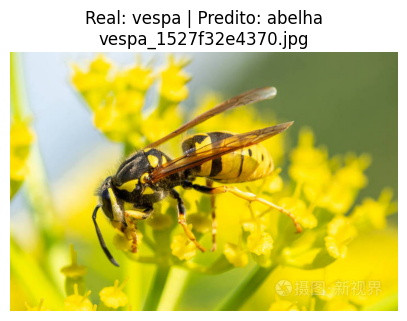

In [73]:
# Inferência com novas imagens (Baidu)
baidu_labels = []
baidu_preds = []
baidu_samples = []

class_names = sorted(class_to_idx.keys())

model.eval()

with torch.no_grad():
    for class_dir in sorted(BAIDU_ROOT.iterdir()):
        if not class_dir.is_dir():
            continue

        true_idx = class_to_idx[class_dir.name]

        for image_path in list_images(class_dir):
            with Image.open(image_path) as img:
                img = img.convert("RGB")

            tensor = preprocess(img).unsqueeze(0).to(device)
            pred_idx = model(tensor).argmax(dim=1).item()

            baidu_labels.append(true_idx)
            baidu_preds.append(pred_idx)
            baidu_samples.append((true_idx, pred_idx, image_path))

baidu_acc = sum(
    label == pred for label, pred in zip(baidu_labels, baidu_preds)
) / len(baidu_labels)

print(f"Imagens Baidu avaliadas: {len(baidu_labels)}")
print("Baidu accuracy:", baidu_acc)

print(confusion_matrix(baidu_labels, baidu_preds))

print(classification_report(
    baidu_labels,
    baidu_preds,
    target_names=class_names,
))

baidu_wrong_predictions = []
for true_idx, pred_idx, image_path in baidu_samples:
    if true_idx == pred_idx:
        continue

    baidu_wrong_predictions.append({
        "image_path": image_path,
        "real_label": idx_to_class[true_idx],
        "pred_label": idx_to_class[pred_idx],
    })

print(f"\nErros Baidu: {len(baidu_wrong_predictions)}")

import matplotlib.pyplot as plt

for wrong in baidu_wrong_predictions:
    image = Image.open(wrong["image_path"]).convert("RGB")

    plt.figure(figsize=(5, 5))
    plt.imshow(image)
    plt.axis("off")
    plt.title(
        f"Real: {wrong['real_label']} | Predito: {wrong['pred_label']}\n"
        f"{wrong['image_path'].name}"
    )
    plt.show()